# Classification

###### COMP4670/8600 - Statistical Machine Learning - Tutorial

In this lab we will build, train, and test a logistic regression classifier.

### Assumed knowledge:

- Optimisation in Python (lab)
- Regression (lab)
- Binary classification with logistic regression (lectures)

### After this lab, you should be comfortable with:

- Implementing logistic regression
- Practical binary classification problems

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as opt

%matplotlib inline

## The data set

We will be working with the census-income dataset, which shows income levels for people in the 1994 US Census. We will predict whether a person has $\leq \$50000$ or $> \$50000$ income per year.

The data are included with this notebook as `02-dataset.tsv`, a textfile where in each row of data, the individual entries are delimited by tab characters.
Load the data into a NumPy array called `data` using `numpy.genfromtxt`:

```python
    numpy.genfromtxt(filename)
```

The column names are given in the variable `columns` below.
The `income` column are the targets, and the other columns will form our data used to try and guess the `income`

In [28]:
columns = ['income', 'age', 'education', 'private-work', 'married', 'capital-gain', 'capital-loss', 'hours-per-week']

In [29]:
data_raw = np.genfromtxt("02-dataset.tsv")

## Recap - Binary classification

The idea behind this lab is that for each person, we want to
try and predict if their income is above the threshold of $\$50,000$ or not,
based on a series of other data about their person: `age, education,...`.

As per usual, for the $n^\text{th}$ row, the first entry is the target $t_n$, and the rest
forms the data vector $\mathbf{x}_n$.

We have two classes, $C_1$ representing the class of $ <\$ 50,000$, which corresponds to
a target of $t_n = 0$, and $C_2$, representing the class of $ >\$50,000$, corresponding to
a target of $t_n = 1$. Our objective is to learn a discriminative function $f_{\mathbf{w}}(\mathbf{x})$,
parametrised by a weight vector $\mathbf{w}$ that
predicts which income class the person is in, based on the data given.

We assume that each piece of information $(t_n, \mathbf{x}_n)$ is i.i.d (independent and identically distributed##), and
that there is some hidden probability distribution from which these target/data points are drawn.
We will construct a likelihood function that indicates "What is the likelihood of this particular
weight vector $\mathbf{w}$ having generated the observed training data $\left\{(t_n, \mathbf{x}_n)\right\}_{n=1}^N$".

## Recap - Feature map, basis function

Now some classes are not linearly seperable (we cannot draw a line such that all of one class is on one side,
and all of the other class is on the other side). But by applying many fixed non-linear 
transformations to the inputs $\mathbf{x}_n$ first, for some suitable choice
of transformation $\phi$ the result will usually be linearly separable
(See week 3, pg 204 of the Bishop Textbook - figure 4.12).##

We let
$$
\mathbf{\phi}_n := \phi(\mathbf{x}_n)
$$

and work in this feature space rather than the input space.
For the case of two classes, we could guess that the target is a linear combination of the features,
$$
\hat{t}_n = \mathbf{w}^T \mathbf{\phi}_n
$$
but $\mathbf{w}^T \mathbf{\phi}_n$ is a real number, and we want $\hat{t}_n \in \{0,1\}$.
We could threshold the result,
$$
\hat{t}_n =
\begin{cases}
1 & \mathbf{w}^T \mathbf{\phi}_n \geq 0 \\
0 & \mathbf{w}^T \mathbf{\phi}_n < 0
\end{cases}
$$
but the discontinuity makes it impossible to define a sensible gradient. 

## Recap - Logistic Regression

(We assume that the classes are already linearly seperable, and use our input space as our feature space.
We also assume the data is i.i.d (independent and identically distributed ##).

Instead of using a hard threshold like above, in logistic regression
we can use the sigmoid function $\sigma(a)$
$$
\sigma(a) := \frac{1}{1 + e^{-a}}
$$
which has the intended effect of "squishing" the real line to the interval $[0,1]$.
This gives a smooth version of the threshold function above, that we can differentiate.
The numbers it returns can be interpreted as a probability of the estimated target $\hat{t}$ belonging
to a class $C_i$ given the element $\phi$ of feature space. In the case of two classes, we define

\begin{align}
p(C_1 | \phi ) &:= \sigma (\mathbf{w}^T \phi_n) = y_n \\
p(C_2 | \phi ) &:= 1 - p(C_1 | \phi_n)= 1- y_n
\end{align}


The likelihood function $p(\mathbf{t} | \mathbf{w}, \mathbf{x})$ is what we want to maximise as a function
of $\mathbf{w}$. Since $\mathbf{x}$ is fixed, we usually write the likelihood function as $p(\mathbf{t} | \mathbf{w})$.

$$
\begin{align}
p(\mathbf{t} | \mathbf{w})
&= \prod_{n=1}^N p(t_n | \mathbf{w}) \\
&= \prod_{n=1}^N 
\begin{cases}
p(C_1 | \phi_n) & t_n = 1 \\
p(C_2 | \phi_n) & t_n = 0
\end{cases}
\end{align}
$$
Note that
$$
\begin{cases}
 y_n & t_n = 1 \\
1 - y_n & t_n = 0
\end{cases}
= y_n^{t_n} (1-y_n)^{1-t_n}
$$
as if $t_n = 1$, then $y_n^1 (1-y_n)^{1-1} = y_n$ and if $t_n = 0$ then $y_n^0 (1-y_n)^{1-0} = 1-y_n$.
This is why we use the strange encoding of $t_n=0$ corresponds to $C_2$ and $t_n=1$ corresponds to $C_1$.
Hence, our likelihood function is 
$$
p(\mathbf{t} | \mathbf{w}) = \prod_{n=1}^N y_n^{t_n} (1-y_n)^{1-t_n}, \quad y_n = \sigma(\mathbf{w}^T \phi_n)
$$
This function is quite unpleasant to try and differentiate, but we note that $p(\mathbf{t} | \mathbf{w})$
is maximised when $\log p(\mathbf{t} | \mathbf{w})$ is maximised.
\begin{align}
\log p(\mathbf{t} | \mathbf{w}) 
&= \log \prod_{n=1}^N y_n^{t_n} (1-y_n)^{1-t_n} \\
&= \sum_{n=1}^N \log \left( y_n^{t_n} (1-y_n)^{1-t_n} \right) \\
&= \sum_{n=1}^N \left( t_n \log y_n +  (1-t_n) \log (1-y_n) \right)
\end{align}
Which is maximised when $- \log p(\mathbf{t} | \mathbf{w})$ is minimised, giving us our error function.
$$
E(\mathbf{w}) := - \sum_{n=1}^N \left( t_n \log y_n +  (1-t_n) \log (1-y_n) \right)
$$
We can then take the derivative of this, which gives us
$$
\nabla_\mathbf{w} E(\mathbf{w}) = \sum_{n=1}^N (y_n - t_n) \phi_n
$$

(Note: We also usually divide the error by the number of data points, to obtain the average error. The error
shouldn't get 10 times as large just because there is more data avaliable, so we should divide by the
number of error points to reflect that.)

## Q1. Derivative of binary cross entropy
The first three questions of this tutorial focus on mathematical derivations of the expressions. Don't spend more than an hour on this before moving onto implementation in questions 4, 5 and 6. 

Take the derivative of $E(\mathbf{w})$, and show that it is equal to the above. Note that the derivative doesn't have any sigmoid functions. (Hint: Use the identity $\sigma'(a) = \sigma(a) \left( 1- \sigma(a) \right)$ to simplify).

### Q1 Solution


$\textbf{Set up} $

So we have $ y_n = \sigma(\mathbf{w}^T \phi_n)$. Recall that the derivative of the sigma function is $\nabla \sigma(x) = \sigma(x) \times (1 - \sigma(x))$.

Since the error function is given by: 

$E(\mathbf{w}) := - \sum_{n=1}^N \left( t_n \log y_n +  (1-t_n) \log (1-y_n) \right)$

Then we have two terms to consider. $\\ $


$\textbf{First Term}$

 Let's start with the $t_n \log y_n$ term. 

$\nabla_w \left( t_n \log y_n \right) = t_n \nabla_w \left( \log(\sigma(\mathbf{w}^T \phi_n))  \right)$

Using the chain rule we get:

$\nabla_w \left( t_n \log y_n \right) = t_n \frac{1}{\sigma(\mathbf{w}^T \phi_n)} \times \sigma(\mathbf{w}^T \phi_n) \times (1 - \sigma(\mathbf{w}^T \phi_n)) \phi_n$

Then cancelling the $\sigma(\mathbf{w}^T \phi_n)$ term gives:

$\nabla_w \left( t_n \log y_n \right) = t_n (1 - \sigma(\mathbf{w}^T \phi_n)) \phi_n$

 $\\ $


$\textbf{Second Term}$

Now considering the $(1-t_n) \log (1-y_n)$ term:

$\nabla_w \left( (1- t_n) \log(1- y_n) \right) = (1-t_n) \nabla_w \left( \log(1-\sigma(\mathbf{w}^T \phi_n))  \right)$

Applying the chain rule gives:

$\nabla_w \left( (1- t_n) \log(1- y_n) \right) = (1-t_n) \times \frac{1}{1-\sigma(\mathbf{w}^T \phi_n)} \times -\sigma(\mathbf{w}^T \phi_n) (1-\sigma(\mathbf{w}^T \phi_n) \times \phi_n )$

Cancelling the $1-\sigma(\mathbf{w}^T \phi_n)$ term gives:

$\nabla_w \left((1- t_n) \log(1- y_n) \right) = - (1-t_n) \sigma(\mathbf{w}^T \phi_n) \phi_n $


 $\\ $


$\textbf{Putting it all Together}$

Combining these gives:

$\nabla_w E(\mathbf{w}) = - \sum_{n=1}^N \left( t_n (1 - \sigma(\mathbf{w}^T \phi_n)) \phi_n  - (1-t_n) \sigma(\mathbf{w}^T \phi_n) \phi_n \right)$

Gathering the $t_n$ terms, factorising and cancelling gives:

$\nabla_w E(\mathbf{w}) = - \sum_{n=1}^N \left( t_n \phi_n - \sigma(\mathbf{w}^T \phi_n) \phi_n \right) $

Then by noting $\sigma(\mathbf{w}^T \phi_n)= y_n$ gives:

$\nabla_w E(\mathbf{w}) = - \sum_{n=1}^N \left( t_n \phi_n - y_n \phi_n \right) $

Cancelling the negatives gives:

$ \nabla_w E(\mathbf{w}) = \sum_{n=1}^N \left(y_n \phi_n - t_n \phi_n \right) $

Done!

## Q2. $L_2$ regularisation, Gaussian prior

Now we consider an isotropic guassian prior for $\mathbf{w}$ (i.e. $w \sim \mathcal{N}(\mathbf{0},\alpha^{-1}I) $). Use the likelihood we derived above and the Gaussian prior, show that the error function could be writen as $$ E(\mathbf{w}) = - \left(\sum_{n=1}^N \left( t_n \log y_n +  (1-t_n) \log (1-y_n) \right)\right) + \frac{\lambda}{2}\Vert \mathbf{w} \Vert_2^2$$ for some $\lambda$. Write out the relation between $\lambda$ and $\alpha$.

For this section of the tutorial we are changing from calculating the log priori to the log posterior likelihood. Start by deriving the negative logarithm of posterior $p(\mathbf{w}|\mathbf{t})$ and discard the constants.

### Q2 Solution:

$
\textbf{Bayes Theorem}
$

By Bayes Theorem we have: $p(w|t) = \frac{p(t|w) p(w)}{p(t)} $. Note to gain our error function we need to take the negative logarithm of this expression:

$ E(\mathbf{w}) = - \log(p(\mathbf{w}|\mathbf{t})) = -\log(p(\mathbf{t}|\mathbf{w}) - \log(p(\mathbf{w})) + \log(p(\mathbf{t}))$

From the working given above we have that the first term is equal to $- \sum_{n=1}^N \left( t_n \log y_n +  (1-t_n) \log (1-y_n) \right)$. The third term does not depend on w and is therefore a constant that can be ignored. 

 $\\ $

$
\textbf{Evaluating Second Term using Multivariate Gaussian}
$

To evaluate the second term of $E(w)$ we need to use the fact that the prior distribution over the weights w is a Gaussian of the form $p(\mathbf{w}) = \mathcal{N}(\mathbf{w}|0, \alpha^{-1} \mathbf{I})$

Note as shown in Bishop eq 1.52 this takes the form: $ \frac{1}{(2 \pi)^{D/2} \times |\alpha^{-1} \mathbf{I}|^{1/2}} \times e ^{-\frac{1}{2}(\mathbf{x} - \mathbf{\mu})^T \mathbf{\Sigma} ^{-1} (\mathbf{x} - \mathbf{\mu})}$.

Taking the negative log of this term and substituting $\mathbf{x} = \mathbf{w}$, $\mathbf{mu} = 0$, $\mathbf{\Sigma} = \alpha^{-1} \mathbf{I} $ gives the second term of $E(\mathbf{w})$ as: 

$
-\log(\frac{1}{(2 \pi)^{D/2} \times |\alpha^{-1} \mathbf{I}|^{1/2}}) + \frac{1}{2}(\mathbf{w} - \mathbf{0})^T \alpha \mathbf{I} (\mathbf{w} - \mathbf{0}) = \textrm{constant} + \frac{1}{2} \mathbf{w}^T \alpha \mathbf{I} \mathbf{w}\\ 
= \textrm{constant} + \frac{\alpha}{2} \mathbf{w}^T  \mathbf{w}\\
=\textrm{constant} + \frac{\alpha}{2} ||\mathbf{w}||_2^2 \\
$

 $\\ $

$
\textbf{Putting it Together}
$

Including all of these terms and discarding the constants gives:

$ E(\mathbf{w}) = - \left(\sum_{n=1}^N \left( t_n \log y_n +  (1-t_n) \log (1-y_n) \right)\right) + \frac{\alpha}{2}\Vert \mathbf{w}\Vert_2^2 $

Therefore by inspection we have $\lambda = \alpha$


## Q3. Derivative of binary cross entropy with regularisation
Take the derivative of $E(\mathbf{w})$ again, accounting for the added regularisation term.

### Solution:

The first term has already been derived in Q1. Taking the derivative of the second term with respect to $\mathbf{w}$ gives $\alpha \mathbf{w}$. Therefore:

$\nabla_w E(\mathbf{w}) = \sum_{n=1}^N \left(y_n \phi_n - t_n \phi_n \right) + \alpha \mathbf{w}$

## Q4. Classification with logistic regression

Implement binary classification using logistic regression and $L_2$ regularisation. Make sure you write good quality code with comments and docstrings where appropriate. In this question, we use the mean error function defined above.

$$ E(\mathbf{w}) = \frac{1}{N}\left\{-\left(\sum_{n=1}^N \left( t_n \log y_n +  (1-t_n) \log (1-y_n)\right)\right) + \frac{\lambda}{2}\Vert \mathbf{w} \Vert_2^2\right\}$$

To optimise your cost function, we will implement a stochastic gradient descent algorithm by hand. We first recall that, in (full-batch) gradient descent, the iteration formula is given by $$ \mathbf{w}_{k+1} = \mathbf{w}_k - \eta\nabla_{\mathbf{w}}E(\mathbf{w}_k),$$ where $\eta$ is the learning rate. For stochastic gradient descent, instead of using the full dataset in each iteration, we will divide the dataset into several mini-batches and use the gradient with respect to one mini-batch to update the parameter in each iteration. Specifically, we first write our regulariser into the sum, 
$$ E(\mathbf{w}) = \frac{1}{N}\sum_{n=1}^N \left\{ -\left(t_n \log y_n +  (1-t_n) \log (1-y_n)\right) \right\} + \frac{\lambda}{2N}\Vert \mathbf{w} \Vert_2^2.$$ Then, for a minibatch $\mathcal{B}_i$ (suppose $\mathcal{B}_i$ is a set of indices), the stochastic gradient $g_{\mathcal{B}_i}$ could be defined as 

$ g_{\mathcal{B}_i}(\mathbf{w}_k) = \nabla_\mathbf{w}\left\{\frac{1}{N_{\mathcal{B}_i}}\sum_{n\in\mathcal{B}_i} \left\{ -\left(t_n \log y_n +  (1-t_n) \log (1-y_n)\right) + \frac{\lambda}{2N}\Vert \mathbf{w} \Vert_2^2 \right\}\right\}\Bigg\vert_{\mathbf{w} = \mathbf{w}_k}$

Differentiating gives:

$ g_{\mathcal{B}_i}(\mathbf{w}_k) = 
\left\{ \frac{1}{N_{\mathcal{B}_i}} \sum_{n\in\mathcal{B}_i}  \left(  (y_n - t_n) \phi_n \right) + \frac{\alpha \mathbf{w}}{N}\right\}\Bigg\vert_{\mathbf{w} = \mathbf{w}_k}.$ 

In each step, the updation formula is given by $$ \mathbf{w}_{k+1} = \mathbf{w}_{k} - \eta g_{\mathcal{B}_i}(\mathbf{w}_k).$$ Note that, for each iteration, we can choose a mini-batch in turn.


By above equations, implement five functions:

- `cost(w, X, t, a, N)`, which calculates the value of the cost function in a mini-batch,
- `grad(w, X, t, a, N)`, which calculates the (stochastic) gradient of the cost function in a mini-batch,
- `create_mini_batches(X_train, t_train, num_batches)`, which creates a list of mini-batch,
- `train(X_train, t_train, a, learning_rate, num_iterations, num_batches)`, which returns the maximum likelihood weight vector using stochastic gradient descent, and
- `predict(w, X)`, which returns predicted class probabilities,

where 
* $\mathbf{w}$ is a weight vector, 
* $X$ is a matrix of examples, 
* $t$ is a vector of labels/targets, 
* $a$ is the regularisation weight. 

(We would use $\lambda$ for the regularisation term, but `a` is easier to type than `lambda`, and
`lambda` is a reserved keyword in python, for lambda functions).

See below for expected usage. We add an extra column of ones to represent the bias term. If you would like further clarification around gradient descent and stochastic gradient descent the tutors recommend [this link](https://towardsdatascience.com/batch-mini-batch-stochastic-gradient-descent-7a62ecba642a).

## Note

* You should use 80% of the data as your training set, and 20% of the data as your test set.
* You also may want to normalise the data before hand. If the magnitude of $\mathbf{w}^T \phi_n$
is very large, the gradient of $\sigma(\mathbf{w}^T \phi_n)$ will be very near zero, which can
cause convergence issues during numerical minimisation. If each element in a particular column is
multiplied by a scalar (say, all elements of the `age` column) then the result is essentially the same
as stretching the space in which the data lives. The model will also be proportionally stretched,
but will not fundamentally change the behaviour. So by normalising each column, we can avoid
issues related to numerical convergence.

In [21]:
assert data_raw.shape[1] == len(columns)
data = np.concatenate([data_raw, np.ones((data_raw.shape[0], 1))], axis=1)  # add a column of ones for bias terms
data.shape

(32561, 9)

In [22]:
# Code for splitting data into train and test with ratio 80/20, DO NOT CHANGE
# This code also normalises the data
np.random.seed(42)

# Shuffle data before splitting
indices = np.random.permutation(data.shape[0])
data = data[indices]

N = np.shape(data)[0]
num_train = int(0.8*N)
t_train = data[:num_train,0]
t_test = data[num_train:, 0]
#number of data points 32561
norm_data = data[:, 1:] / (data[:, 1:].sum(axis=0, keepdims=True)) # Divides each column by the sum of entries in that column. 
X_train = norm_data[:num_train, :]
X_test = norm_data[num_train:, :]
assert X_test.shape[1] == len(columns)
x_columns = columns[1:] + ['bias']


### Q4a. Define the loss and gradient
Implement the logistic sigmoid function, the binary cross entropy, the stochastic gradient of the error function using a mini-batch of training points, and the batch gradient using the full training set.

In [23]:
# Note in these functions we treat phi as X
# The following two lines have been included to assist you in checking your answer
np.random.seed(42)
w = np.random.randn(X_train.shape[1])


def sigmoid(a):
    return 1/(1+np.exp(-a))

print(f"True Sigmoid output value: {0.7311}")
print(f"Your Sigmoid output value: {sigmoid(1):.4f}")
print()

def cost(w, X, t, a, N): # N is the total sample size
    y = sigmoid(X @ w) # evaluates y
    squared_L2_norm_w = w.T @ w #finds the squared L2 vector norm of w
    E = -1/N *(t @ np.log(y) + (1-t) @ np.log(1-y)  + a/2* squared_L2_norm_w)
    return E
    
print(f"Cost Function Should Output: {0.6932}")
print(f"Your Cost Function Output: {cost(w, X_train, t_train, 0.1, X_train.shape[0]):.4f}")
print()
    
def stochastic_grad(w, X, t, a, N, N_batch): # N is the total sample size, N_batch is the size of the batch
    y = sigmoid(X @ w)
    t=t.reshape((-1,)) #This line turns a matrix t (n,1) into a vector (n,)
    g_Bi =  1/N_batch *((y - t) @ X) + (a/N)*w 
    ## Needs to be output with
    return g_Bi

print(f"Stochastic Gradient Should Output: [ 0.00139253  0.0013798   0.00174056  0.0004018  -0.00245008 -0.00020142 0.00142549  0.00160559]")
print(f"Your Stochastic Gradient Output: {stochastic_grad(w, X_train, t_train, 0.1, 26048, 130)}")
print()

def batch_grad(w, X, t, a, N):  # N is the total sample size
    #Gradient calculation if batches were not being used
    y = sigmoid(X @ w)
    
    grad = 1/N*(((y-t)@X) + a*w)
    return grad

print(f"Batch Gradient Should Output: [ 8.84723058e-06  6.35812434e-06  1.11608567e-05  7.82310932e-06 -1.31222911e-05 -1.89962576e-06  1.31467834e-05  1.09446864e-05]")
print(f"Your Batch Gradient Output: {batch_grad(w, X_train, t_train, 0.1, 26048)}")

True Sigmoid output value: 0.7311
Your Sigmoid output value: 0.7311

Cost Function Should Output: 0.6932
Your Cost Function Output: 0.6932

Stochastic Gradient Should Output: [ 0.00139253  0.0013798   0.00174056  0.0004018  -0.00245008 -0.00020142 0.00142549  0.00160559]
Your Stochastic Gradient Output: [ 0.001379    0.00136724  0.00174293  0.00039756 -0.00237659 -0.00021856
  0.00141544  0.00159803]

Batch Gradient Should Output: [ 8.84723058e-06  6.35812434e-06  1.11608567e-05  7.82310932e-06 -1.31222911e-05 -1.89962576e-06  1.31467834e-05  1.09446864e-05]
Your Batch Gradient Output: [ 8.77971362e-06  6.29543794e-06  1.11727058e-05  7.80195597e-06
 -1.27555065e-05 -1.98518634e-06  1.30966095e-05  1.09069620e-05]


### Q4b. Divide mini-batches
Given the training set and the number of minibatches we want, implement the function `create_mini_batches` which will return a list of tuples such that each tuple represents a mini-batch which contains features and corresponding targets. (i.e. the output should be $[(X_1,t_1), (X_2,t_2), \ldots, (X_{num\_batches},t_{num\_batches})])$

Hint: Use `np.random.shuffle()` to shuffle the dataset first. Make sure training data are spread as evenly as you can.

In [24]:
np.random.seed(42)

def create_mini_batches(X_train, t_train, num_batches):
    mini_batches = []
    data = np.hstack((X_train, t_train.reshape((X_train.shape[0],1))))
    np.random.shuffle(data)
    batch_size = data.shape[0] // num_batches
    
    for i in range(num_batches):
        mini_batch = data[i * batch_size:(i+1)*batch_size,:]
        X_mini = mini_batch[:,:-1]
        Y_mini = mini_batch[:,-1].reshape((-1,1))
        mini_batches.append((X_mini, Y_mini))
    return mini_batches

## Note that to be compatible with the rest of the tutorial:
## create_mini_batches() should produce a list of tuples of numpy ndarrays.

## For the test case below:
## The List should have a length of 200 (batches)
## The tuples should have 2 entries: each batch should have an array of features for the minibatch and an array of corresponding targets
## The Arrays should have dimensions (130,8) for X and (130, 1) for Y


print(f"An example solution code could produce: [2.94525722e-05 3.35123706e-05 4.40606274e-05 6.48634624e-05 0.00000000e+00 0.00000000e+00 3.03793469e-05 3.07115875e-05] for an entry in a batch of Features")
print(f"and: [0.] for an entry in a batch of targets")

print()

print(f"Your code produces: {create_mini_batches(X_train, t_train, 200)[0][0][0]}for an entry in a batch of Features")
print(f"and: {create_mini_batches(X_train, t_train, 200)[0][1][0]} for the corresponding entry in a batch of targets")



An example solution code could produce: [2.94525722e-05 3.35123706e-05 4.40606274e-05 6.48634624e-05 0.00000000e+00 0.00000000e+00 3.03793469e-05 3.07115875e-05] for an entry in a batch of Features
and: [0.] for an entry in a batch of targets

Your code produces: [3.26366341e-05 2.74192123e-05 4.40606274e-05 0.00000000e+00
 0.00000000e+00 0.00000000e+00 3.79741836e-05 3.07115875e-05]for an entry in a batch of Features
and: [0.] for the corresponding entry in a batch of targets


### Q4c. Train the model
Implement the function `train(mini_batches, a, learning_rate, num_iterations)` which returns the maximum likelihood weight vector using stochastic gradient descent. You can tune your `learning_rate` and `num_iterations` to attain better performance. 

Hint: You can try to plot the loss-iteration curve to make sure your algorithm converge properly.

In [25]:
# Code for training the model and making predictions

def train(X_train, t_train, a, learning_rate, num_iterations, num_batches):  # a is regularisation parameter
    
    # Keep track of loss value
    loss_his = []
    
    # Create mini-batches
    mini_batches = create_mini_batches(X_train, t_train, num_batches)
    
    # Initialise parameter
    w = np.random.randn(X_train.shape[1])
    
    # Train
    for i in range(num_iterations):
        batch_num = np.mod(i, num_batches)-1
        s_grad = stochastic_grad(w, mini_batches[batch_num][0], mini_batches[batch_num][1],a, 32561,mini_batches[batch_num][0].shape[0])
        w -= learning_rate * s_grad
        loss = cost(w, X_train, t_train, a, X_train.shape[0])
        loss_his.append(loss)
        
        # print the loss per 1000 iters
        if np.mod(i,1000) == 0:
            print("*"*40)
            print("The loss in iteration ",i, " is ",loss)
    
    
    plt.xlabel("# iterations")
    plt.ylabel("loss")
    plt.plot(loss_his)
    
    return w

def predict(w, X):
    return sigmoid(X @ w)
    


### Q4d. Make predictions
Use the code above to train your model by calculating the weights for your model and making predictions for the test data.

Hint: Compare your training loss with the one using `opt.fmin_bfgs`, your resulting loss should be better or roughly equal to the one computed by inbuilt functions.
This is not easy to train, please restart and potentially tune the hyperparameters if youre loss diverge or you get a bad generalisation.

****************************************
The loss in iteration  0  is  0.6931280540386873
****************************************
The loss in iteration  1000  is  0.6931242143409188
****************************************
The loss in iteration  2000  is  0.693120346277577
****************************************
The loss in iteration  3000  is  0.6931164593411424
****************************************
The loss in iteration  4000  is  0.6931125622213926
****************************************
The loss in iteration  5000  is  0.6931086628604256
****************************************
The loss in iteration  6000  is  0.6931047685042401
****************************************
The loss in iteration  7000  is  0.6931008857510012
****************************************
The loss in iteration  8000  is  0.6930970205962117
****************************************
The loss in iteration  9000  is  0.6930931784750286
****************************************
The loss in iteration  10000  is 

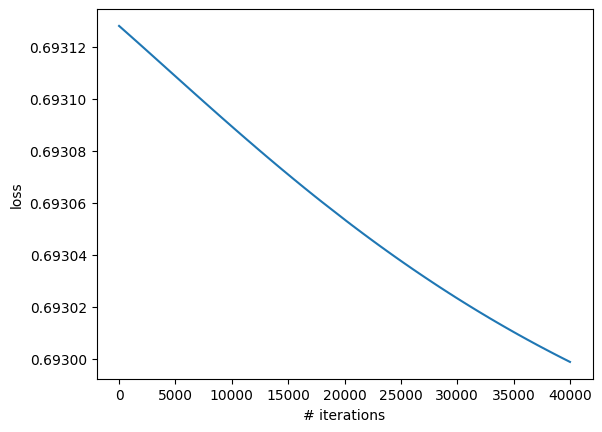

In [26]:
np.random.seed(42)
w_train = train(X_train, t_train, 0.1, 10, 40000, 200) 

# TODO：This is not easy to train, please restart and potentially tune the hyperparameters if youre loss diverge or you get a bad generalisation.
print('Your training loss is:')
print(cost(w_train, X_train, t_train, 0.1, X_train.shape[0]))
w_train_bfgs = opt.fmin_bfgs(
        f=cost, fprime=batch_grad, x0=np.random.normal(scale=0.2, size=(X_train.shape[1],)), args=(X_train, t_train, 0.1, X_train.shape[0]), disp=0)
print('The training loss using opt.fmin_bfgs is:')
print(cost(w_train_bfgs, X_train, t_train, 0.1, X_train.shape[0]))
t_test_pred = sigmoid(X_test @ w_train)  # TODO

# Codes for displaying the results
print('The predictions are:')
print(t_test_pred)
print('The trained parameters are:')
print(w_train)


## Q5. Performance measure

There are many ways to compute the performance of a binary classifier. The key concept is the idea of a confusion matrix:

|     &nbsp;         | &nbsp;  | Label | &nbsp;  |
|:-------------:|:--:|:-----:|:--:|
|     &nbsp;         |  &nbsp;  |  0    | 1  |
|**Prediction**| 0  |    TN | FN |
|      &nbsp;        | 1  |    FP | TP |

where
* TP - true positive
* FP - false positive
* FN - false negative
* TN - true negative

Implement three functions:

- `confusion_matrix(y_true, y_pred)`, which returns the confusion matrix as a list of lists given a list of true labels and a list of predicted labels;
- `accuracy(cm)`, which takes a confusion matrix and returns the accuracy; and
- `balanced_accuracy(cm)`, which takes a confusion matrix and returns the balanced accuracy.

The accuracy is defined as $\frac{TP + TN}{n}$, where $n$ is the total number of examples. The balanced accuracy is defined as $\frac{1}{2}\left(\frac{TP}{P} + \frac{TN}{N}\right)$, where $T$ and $N$ are the total number of positive and negative examples respectively.

In [18]:
# solution

def confusion_matrix(t_true, t_pred):
    assert len(t_true) == len(t_pred)
    
    #Converts predictions to boolean values
    for i in range(np.shape(t_test_pred)[0]):
        if t_test_pred[i] >= 0.5:
            t_test_pred[i] = 1    
        else:
            t_test_pred[i] = 0
    
    #Counts the number of results which fall into each entry of the matrix
    TP = 0
    TN = 0
    FP = 0
    FN = 0
    for i in range(len(t_true)):
        if t_pred[i] == 1:
            if t_true[i] == 1:
                TP += 1
            else:
                FP += 1
        else:
            if t_true[i] == 0:
                TN += 1
            else:
                FN += 1
    return [[TN,FN],[FP,TP]]



def accuracy(cm):
    return float((cm[0][0]+cm[1][1]))/(cm[0][0]+cm[1][0]+cm[0][1]+cm[1][1])
    
def balanced_accuracy(cm):
    return 0.5*(float(cm[0][0])/(cm[0][0]+cm[1][0]) +float(cm[1][1])/(cm[0][1]+cm[1][1]) )



## Accuracy vs balanced accuracy

What is the purpose of balanced accuracy? When might you prefer it to accuracy?

### Solution
Balanced accuracy is more useful when a large portion of the data belong to a single class. 
For our particular data set imagine that the country being considered is very poor and almost no one earns more than \\$50,000 per year. In this case if we used normal accuracy our model could simply train to always predict 0 regardless of the input variables. However if we used balanced accuracy then the model would be punished severely for not correctly predicting cases where have incomes higher than \\$50,000 thus encouraging better classification than always predicting 0.

## Putting everything together

Consider the following code which computes the accuracy and balanced accuracy. Discuss the results. (Your accuracy shoud be better than `[0.75,0.5]`)

In [19]:
cmatrix = confusion_matrix(t_test, t_test_pred)

print(cmatrix)

[accuracy(cmatrix), balanced_accuracy(cmatrix)]

[[4882, 1247], [63, 321]]


[0.7988638108398587, 0.5959896230989868]

The accuracy is higher than the balanced accuracy, which indicates a strong class imbalance in the dataset and that the model may be biased toward predicting the majority class.

## Q6. Looking back at the prediction task

Based on your results, what feature of the dataset is most useful for determining the income level? What feature is least useful? Why?

Hint: take a look at ```w_train```.

('age', -1.7408213578350136)
('education', -1.4400567820402408)
('private-work', -2.4834276155645925)
('married', -0.6041379472179191)
('capital-gain', 2.539598305543604)
('capital-loss', 0.27888577310804574)
('hours-per-week', -1.4876941127526402)
('bias', -2.0221770051432495)
capital-gain is the most important feature as it has the highest magnitude of weight


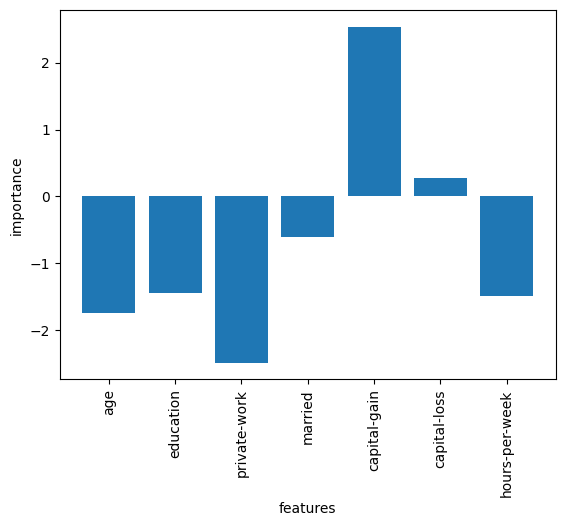

In [20]:
assert len(w_train) == len(x_columns)
plt.bar(range(len(w_train)-1), w_train[:-1])
plt.ylabel('importance')
plt.xlabel('features')
plt.xticks(range(len(w_train)-1), x_columns[:-1], rotation='vertical');
print('\n'.join(map(str, list(zip(x_columns, w_train)))))

# ignore the last weight (bias):
i_w_abs_max = np.argmax(np.abs(w_train[:-1])) 
# skip the first column, which is for the target
print(x_columns[i_w_abs_max], 'is the most important feature as it has the highest magnitude of weight')


## Textbook Questions (Optional)
These questions are hand picked to both be of reasonable difficulty and demonstrate what you are expected to be able to solve. The questions are labelled in Bishop as either $\star$, $\star\star$, or $\star\star\star$ to rate its difficulty.

- **Question 4.4**: If you are unfamiliar with lagrange multipliers, look at Appendix E of the textbook. (Difficulty $\star$, simple algebraic derivation)
- **Question 4.5**: (Difficulty $\star$, simple algebraic derivation)
- **Question 1.24**: Note that in the equation $L_{kj}=1-I_{kj}$, $I$ is the identity matrix, so if $k=j$ then $I_{kj}=1$ and $L_{kj}=1-1=0$. (Difficulty $\star\star$, requires good understanding of the formulation of how to minimise expected loss)
- **Question 1.25**: This requires calculus of variations (used much more later in the course), which is in Appendix D, specifically the Euler-Lagrange result. Assume that everything is continuous and continuously differentiable so that you can bring the differentiation inside the integral sign. (Difficulty $\star$, simple extension of proof in textbook to multiple target variables)
- **Question 4.9**: First state the likelihood. When maximising this, what constraints need to be set? Given such constraints, use lagrange multipliers to derive the results. (Difficulty $\star$, simple algebraic derivation)
- **Question 4.10**: For the covariance matrix, you should be able to only use identities from [Sam Roweis' Matrix Identities](https://cs.nyu.edu/~roweis/notes/matrixid.pdf) to derive the result. Note you can use the cyclic property on $$(x_n-\mu_k)^T\Sigma^{-1}(x_n-\mu_k)$$ as it is a square matrix (scalar). (Difficulty $\star\star$, covariance matrix derivation requires uncommon identities)
- **Question 4.11**: (Difficulty $\star\star$, short derivation but requires understanding what the question setup allows you to apply)
- **Question 4.12**: (Difficulty $\star$, simple algebraic derivation)

